In [9]:
import numpy as np
import matplotlib.pyplot as plt
import random as rnd

In [10]:
# Configuración de semillas para asegurar la replicabilidad (Verificación)
rnd.seed(42)
np.random.seed(42)

In [11]:
def simular_sistema_parqueadero(tiempo_simulacion=480):
    """
    Simula el comportamiento de un cajero independiente M/M/1.
    Aplica las distribuciones de llegada y servicio según el tipo de usuario.
    """
    categorias = ['Rápido', 'Normal', 'Lento', 'Muy Lento']
    probabilidades = [0.25, 0.20, 0.275, 0.275] # 25% rápido, 20% normal, 55% restante dividido

    medias_servicio = {'Rápido': 1.0, 'Normal': 3.0, 'Lento': 4.0, 'Muy Lento': 6.0}
    medias_llegada = {'Rápido': 3.0, 'Normal': 3.0, 'Lento': 5.0, 'Muy Lento': 7.0}

    # Tasa de llegada global ponderada (Lambda total)
    lambda_total = sum(p / medias_llegada[cat] for cat, p in zip(categorias, probabilidades))
    media_llegada_global = 1.0 / lambda_total

    # Variables de estado y tiempos
    reloj = 0.0
    proxima_llegada = reloj - media_llegada_global * np.log(rnd.random())
    proximo_servicio = float('inf')

    cola = 0
    registro_cola = []

    # Listas para almacenar métricas de salida
    tiempos_atencion = []
    tipos_usuarios = []
    tiempos_espera = []
    ev_tiempo_promedio = [] # Para análisis de estado estable

    while reloj < tiempo_simulacion or cola > 0:
        # Determinar el evento más próximo
        if proxima_llegada < proximo_servicio and reloj < tiempo_simulacion:
            # EVENTO: LLEGADA
            reloj = proxima_llegada
            cola += 1

            # Asignar tipo de usuario estocásticamente
            tipo_u = np.random.choice(categorias, p=probabilidades)
            registro_cola.append((reloj, tipo_u))

            # Programar siguiente llegada
            proxima_llegada = reloj - media_llegada_global * np.log(rnd.random())

            if cola == 1:
                # Servidor ocioso: inicia atención inmediatamente
                t_llegada, t_usuario = registro_cola.pop(0)
                tiempos_espera.append(0.0)

                mu_indiv = medias_servicio[t_usuario]
                tiempo_serv = -mu_indiv * np.log(rnd.random())
                proximo_servicio = reloj + tiempo_serv

                tiempos_atencion.append(tiempo_serv)
                tipos_usuarios.append(t_usuario)
                ev_tiempo_promedio.append(np.mean(tiempos_atencion))

        else:
            # EVENTO: FIN DE SERVICIO
            if cola > 0:
                reloj = proximo_servicio
                cola -= 1
                proximo_servicio = float('inf')

                if cola > 0:
                    # Atender al siguiente en la fila (FIFO)
                    t_llegada, t_usuario = registro_cola.pop(0)
                    tiempos_espera.append(reloj - t_llegada)

                    mu_indiv = medias_servicio[t_usuario]
                    tiempo_serv = -mu_indiv * np.log(rnd.random())
                    proximo_servicio = reloj + tiempo_serv

                    tiempos_atencion.append(tiempo_serv)
                    tipos_usuarios.append(t_usuario)
                    ev_tiempo_promedio.append(np.mean(tiempos_atencion))
            else:
                break

    return tiempos_atencion, tipos_usuarios, tiempos_espera, ev_tiempo_promedio

In [12]:
# ==========================================
# 1. EJECUCIÓN DE LA SIMULACIÓN (3 CAJEROS)
# ==========================================
cajeros = ['Cajero 1', 'Cajero 2', 'Cajero 3']
resultados = {}

for c in cajeros:
    ta, tu, te, ev = simular_sistema_parqueadero(tiempo_simulacion=480) # Jornada de 8 horas
    resultados[c] = {
        'tiempos_atencion': ta,
        'tipos_usuarios': tu,
        'tiempos_espera': te,
        'evolucion_promedio': ev
    }

<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_10151/3679283087.py:13: SyntaxWarning: invalid escape sequence '\m'
  plt.axhline(y=3.67, color='black', linestyle='--', alpha=0.7, label='Media Teórica Esperada ($\mu_{global}$)')


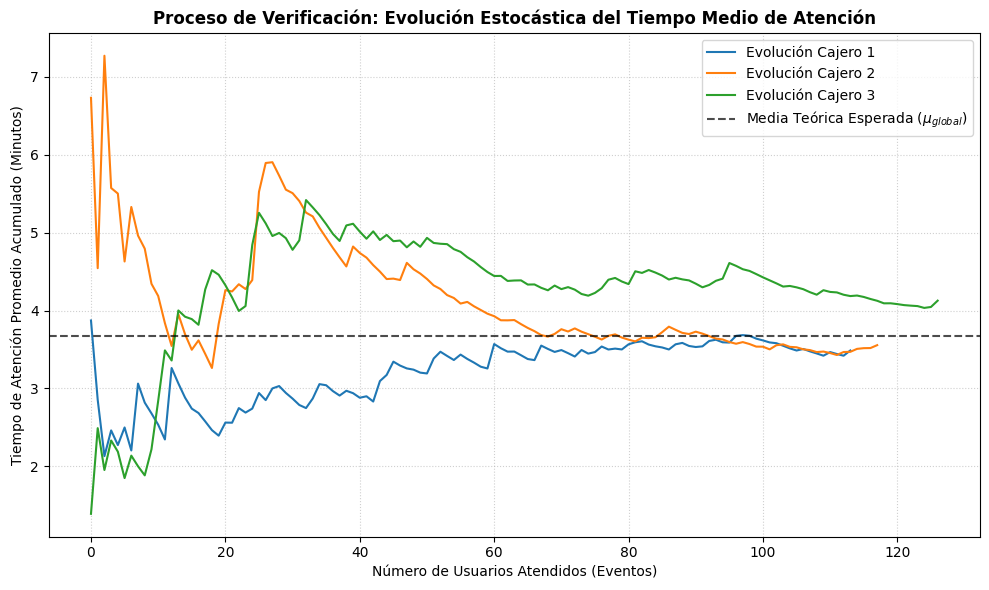

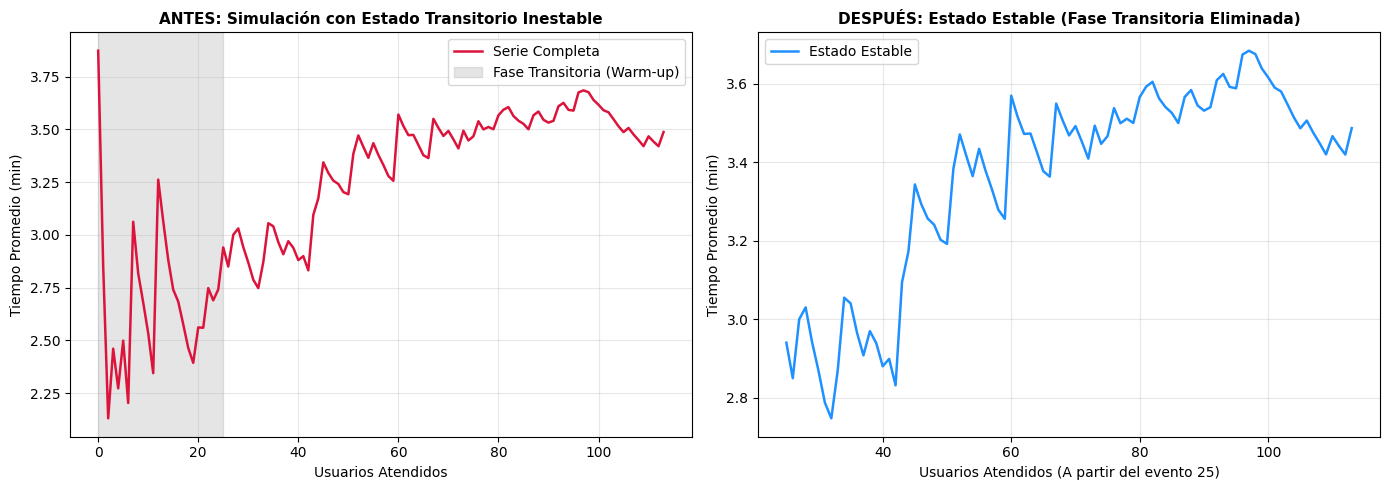

In [13]:
# ==========================================
# 2. PROCESAMIENTO GRÁFICO (MATPLOTLIB)
# ==========================================

# --- GRÁFICA 1: PROCESO DE VERIFICACIÓN Y EVOLUCIÓN (Punto D) ---
plt.figure(figsize=(10, 6))
for c in cajeros:
    plt.plot(resultados[c]['evolucion_promedio'], label=f'Evolución {c}')

plt.title('Proceso de Verificación: Evolución Estocástica del Tiempo Medio de Atención', fontsize=12, fontweight='bold')
plt.xlabel('Número de Usuarios Atendidos (Eventos)')
plt.ylabel('Tiempo de Atención Promedio Acumulado (Minutos)')
plt.axhline(y=3.67, color='black', linestyle='--', alpha=0.7, label='Media Teórica Esperada ($\mu_{global}$)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# --- GRÁFICA 2: ANTES Y DESPUÉS - ELIMINACIÓN DEL ESTADO TRANSITORIO (Punto E) ---
# Tomamos el Cajero 1 como base de análisis bajo la técnica de Welch / Ventana de Calentamiento
serie_original = resultados['Cajero 1']['evolucion_promedio']

# Definimos el punto de corte (Warm-up period) tras observar la estabilización (ej. 25 usuarios)
ventana_calentamiento = 25
serie_estable = serie_original[ventana_calentamiento:]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Subgráfica del "Antes" (Incluye la alta variabilidad inicial del estado transitorio)
ax1.plot(serie_original, color='crimson', linewidth=1.8, label='Serie Completa')
ax1.axvspan(0, ventana_calentamiento, color='gray', alpha=0.2, label='Fase Transitoria (Warm-up)')
ax1.set_title('ANTES: Simulación con Estado Transitorio Inestable', fontsize=11, fontweight='bold')
ax1.set_xlabel('Usuarios Atendidos')
ax1.set_ylabel('Tiempo Promedio (min)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Subgráfica del "Después" (Estado estable puro)
usuarios_estables = range(ventana_calentamiento, len(serie_original))
ax2.plot(usuarios_estables, serie_estable, color='dodgerblue', linewidth=1.8, label='Estado Estable')
ax2.set_title('DESPUÉS: Estado Estable (Fase Transitoria Eliminada)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Usuarios Atendidos (A partir del evento 25)')
ax2.set_ylabel('Tiempo Promedio (min)')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

In [14]:
# ==========================================
# 3. CÁLCULO DE ESTADÍSTICAS PARA EL REPORTE
# ==========================================
print("\n" + "="*45)
print("ESTADÍSTICAS CONSOLIDADAS PARA EL INFORME")
print("="*45)

# A. Tiempo promedio por cajero
print("\nA. Tiempo promedio de atención por cajero:")
for c in cajeros:
    media = np.mean(resultados[c]['tiempos_atencion'])
    print(f" - {c}: {media:.2f} minutos")

# B. Promedio de usuarios por tipo en la totalidad de cajeros
print("\nB. Conteo total de usuarios atendidos por tipo (Totalidad de Cajeros):")
todos_los_tipos = []
for c in cajeros:
    todos_los_tipos.extend(resultados[c]['tipos_usuarios'])

for u_tipo in ['Rápido', 'Normal', 'Lento', 'Muy Lento']:
    cantidad = todos_los_tipos.count(u_tipo)
    print(f" - Usuarios de tipo [{u_tipo}]: {cantidad} atendidos")


ESTADÍSTICAS CONSOLIDADAS PARA EL INFORME

A. Tiempo promedio de atención por cajero:
 - Cajero 1: 3.49 minutos
 - Cajero 2: 3.56 minutos
 - Cajero 3: 4.13 minutos

B. Conteo total de usuarios atendidos por tipo (Totalidad de Cajeros):
 - Usuarios de tipo [Rápido]: 96 atendidos
 - Usuarios de tipo [Normal]: 67 atendidos
 - Usuarios de tipo [Lento]: 102 atendidos
 - Usuarios de tipo [Muy Lento]: 94 atendidos
